In [1]:
import numpy as np
from astropy.io import fits
from scipy.ndimage import map_coordinates

# Load the F200W, F356W, and F444W FITS files
fits_files = ['source/F200W.fits', 'source/F356W.fits', 'source/F444W.fits']
hduls = [fits.open(fits_file) for fits_file in fits_files]
headers = [hdul[0].header for hdul in hduls]
pixel_scales = [header['PIXSCALE'] for header in headers]
data = [hdul[0].data for hdul in hduls]
hpfrdi_images = [d[:,:,1] for d in data]
deconv_images = [d[:,:,0] for d in data]

# Load the throughput_recover FITS files
throughput_files = ['source/throughput_recover_F200W.fits', 'source/throughput_recover_F356W.fits', 'source/throughput_recover_F444W.fits']
throughput_hduls = [fits.open(fits_file) for fits_file in throughput_files]
throughput_images = [hdul[0].data for hdul in throughput_hduls]

HPFRDI Images Photometry
Filter: F200W
Adjusted inner radius for image 0 to 2.42 pixels based on 1 lambda/D.
Processing took: 18.4241 seconds
Mean Total Flux: 8.261598 mJy
Standard Deviation of Total Flux: 0.004021 mJy


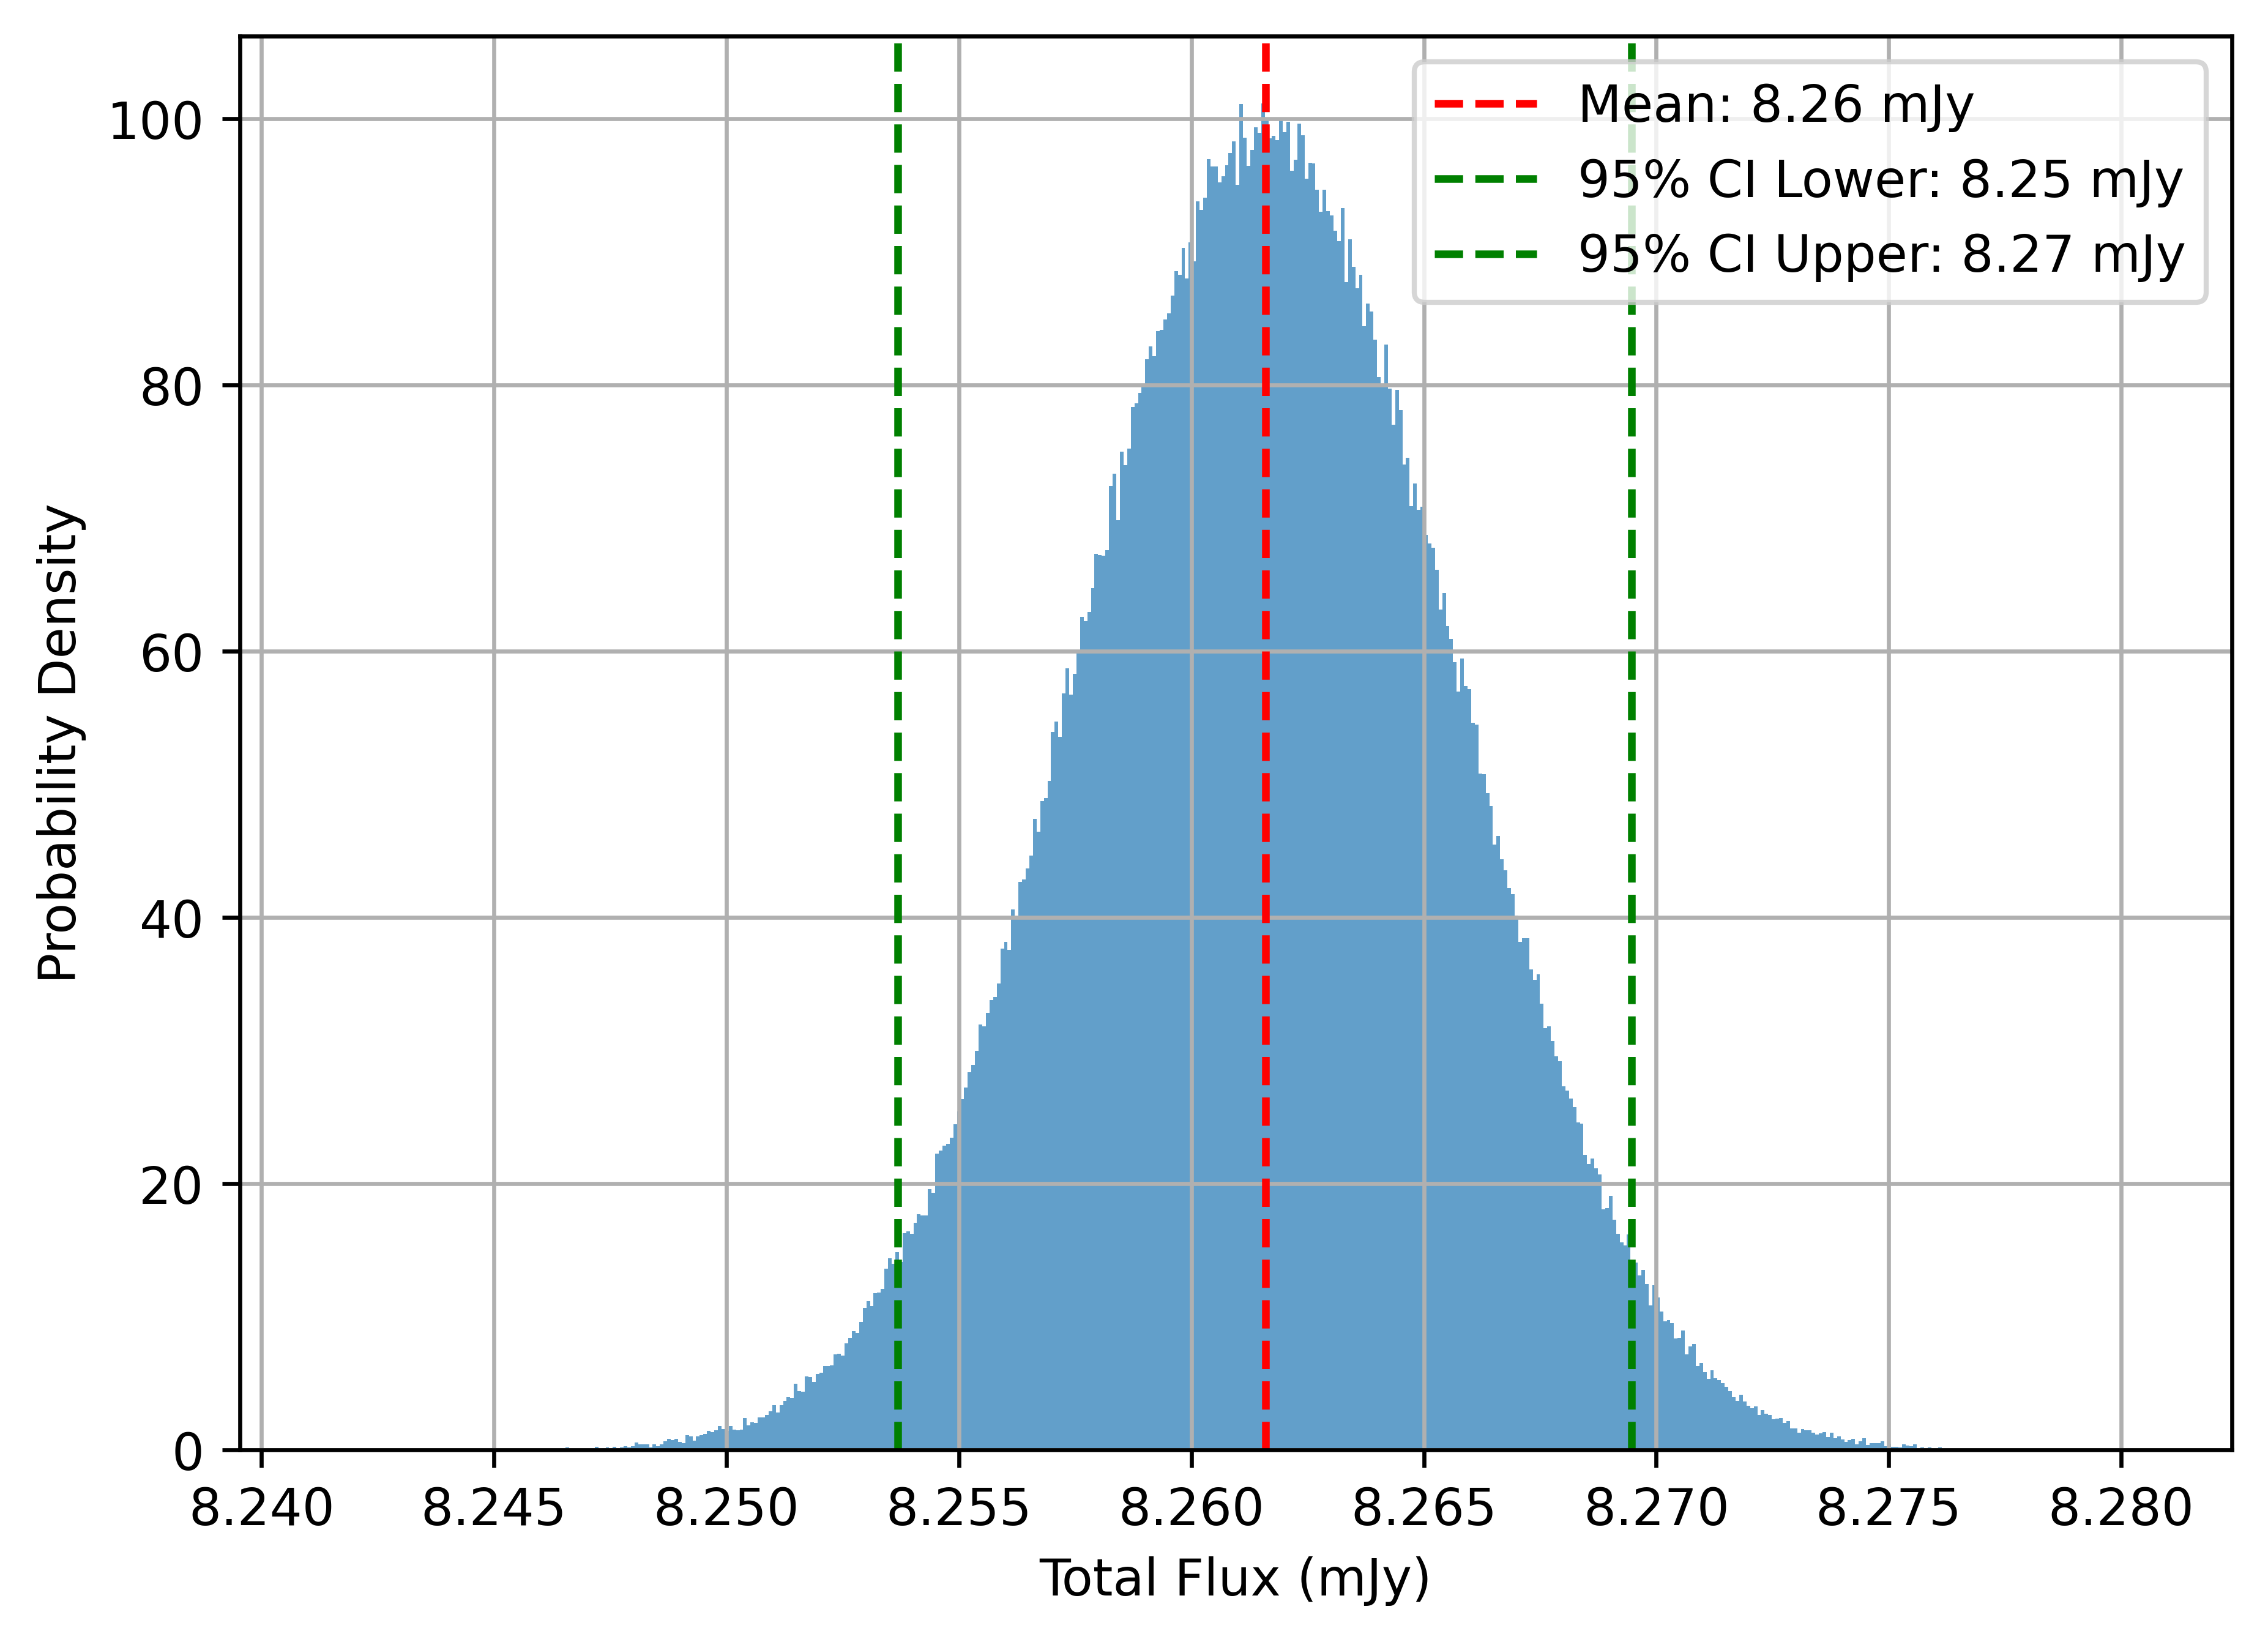

Filter: F356W
Adjusted inner radius for image 1 to 1.27 pixels based on 1 lambda/D.
Processing took: 17.8231 seconds
Mean Total Flux: 2.186898 mJy
Standard Deviation of Total Flux: 0.004102 mJy


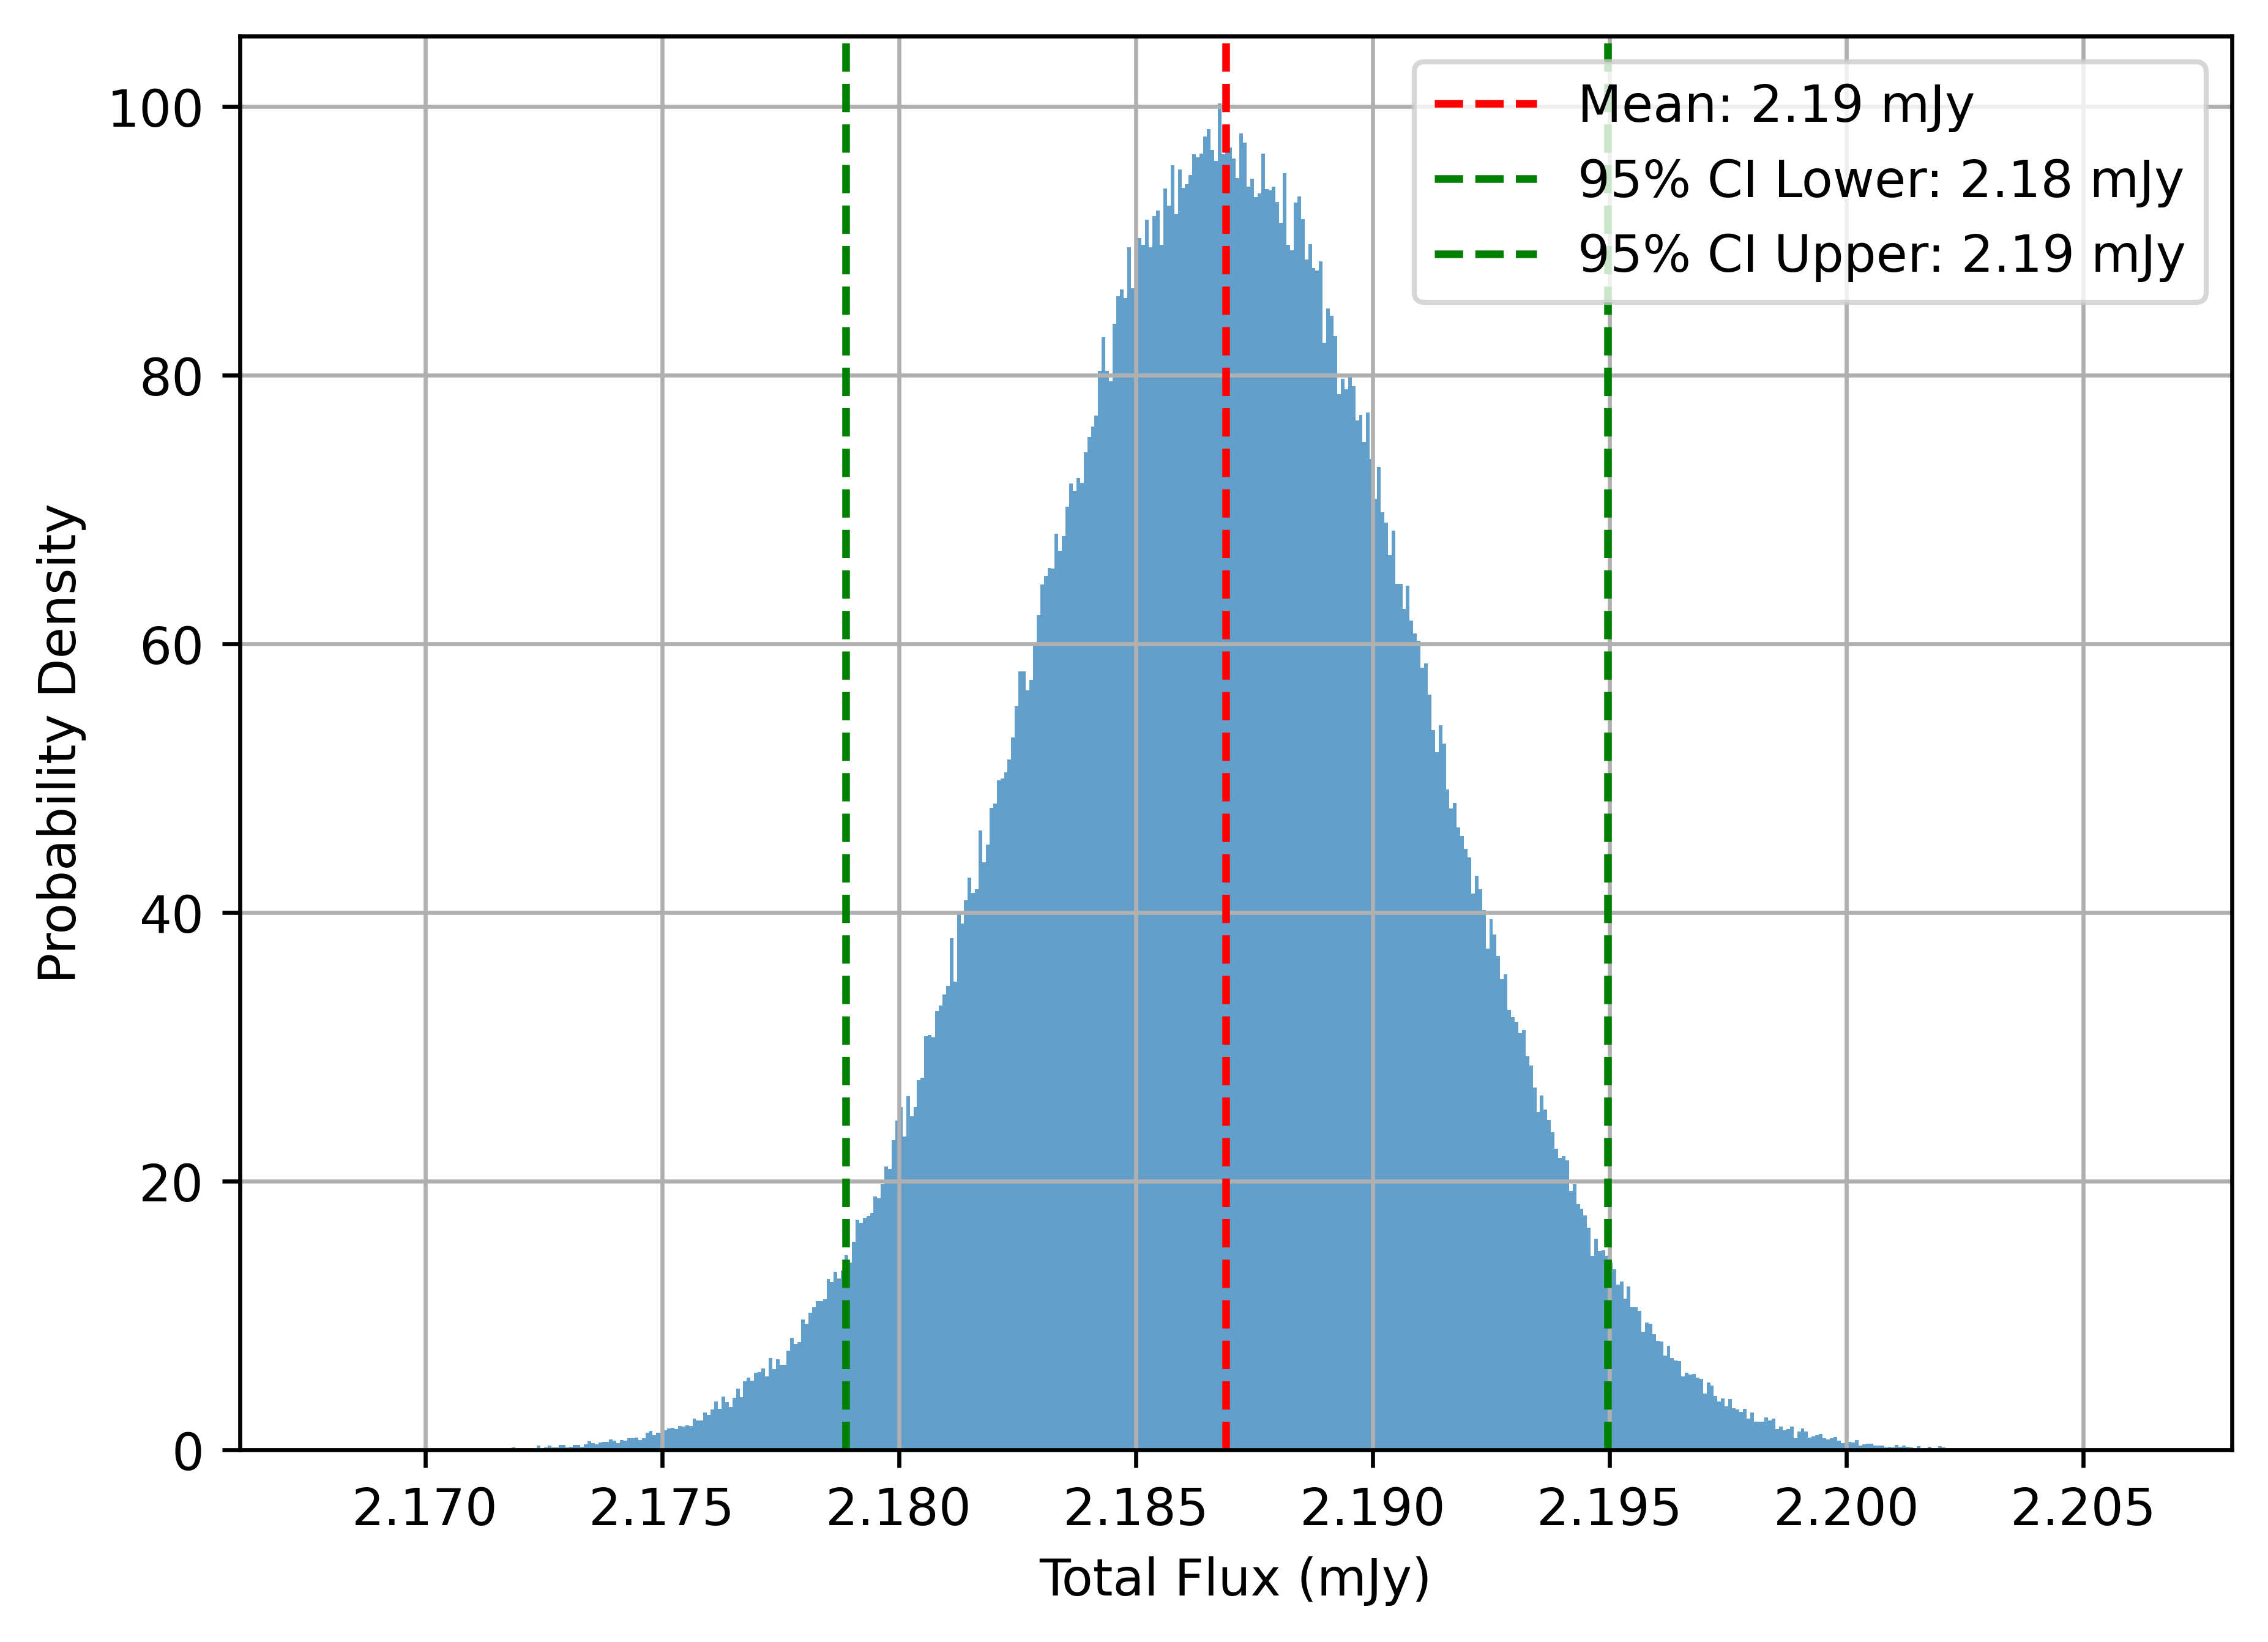

Filter: F444W
Adjusted inner radius for image 2 to 2.26 pixels based on 1 lambda/D.
Processing took: 18.2897 seconds
Mean Total Flux: 1.159143 mJy
Standard Deviation of Total Flux: 0.005825 mJy


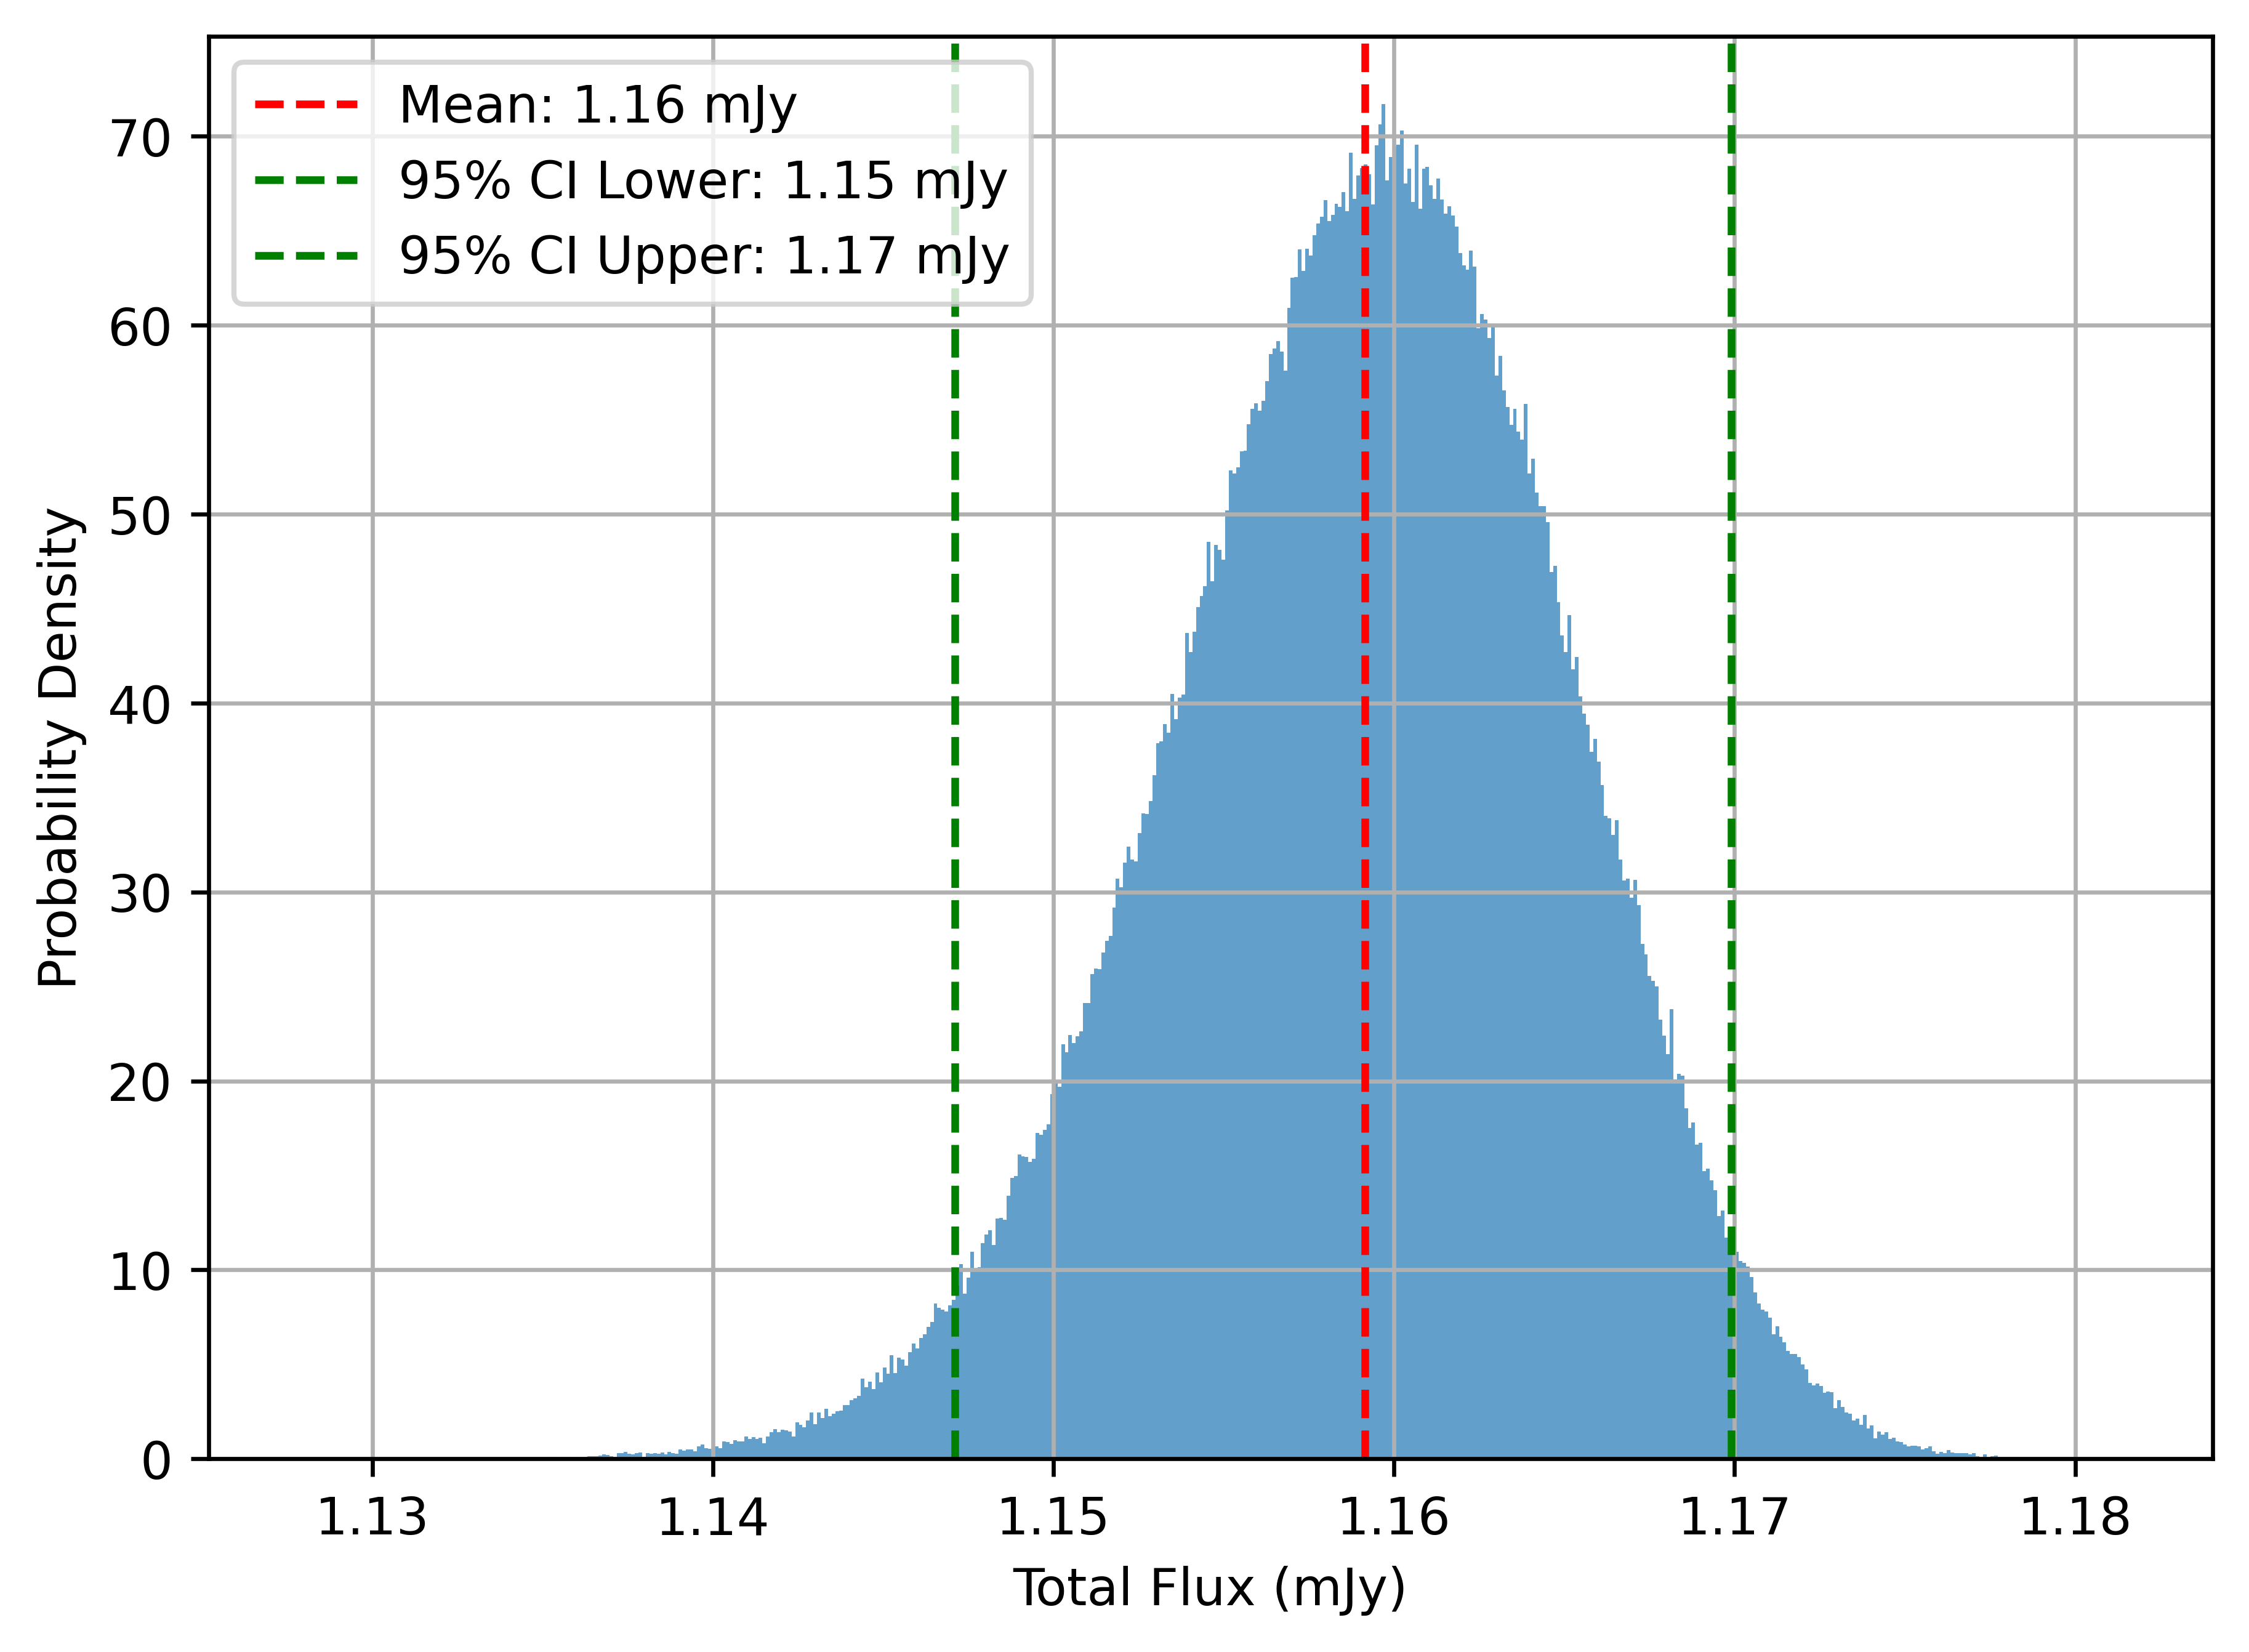



Deconvolved Images Photometry
Filter: F200W
Adjusted inner radius for image 0 to 2.42 pixels based on 1 lambda/D.
Processing took: 17.3480 seconds
Mean Total Flux: 19.935692 mJy
Standard Deviation of Total Flux: 0.313885 mJy


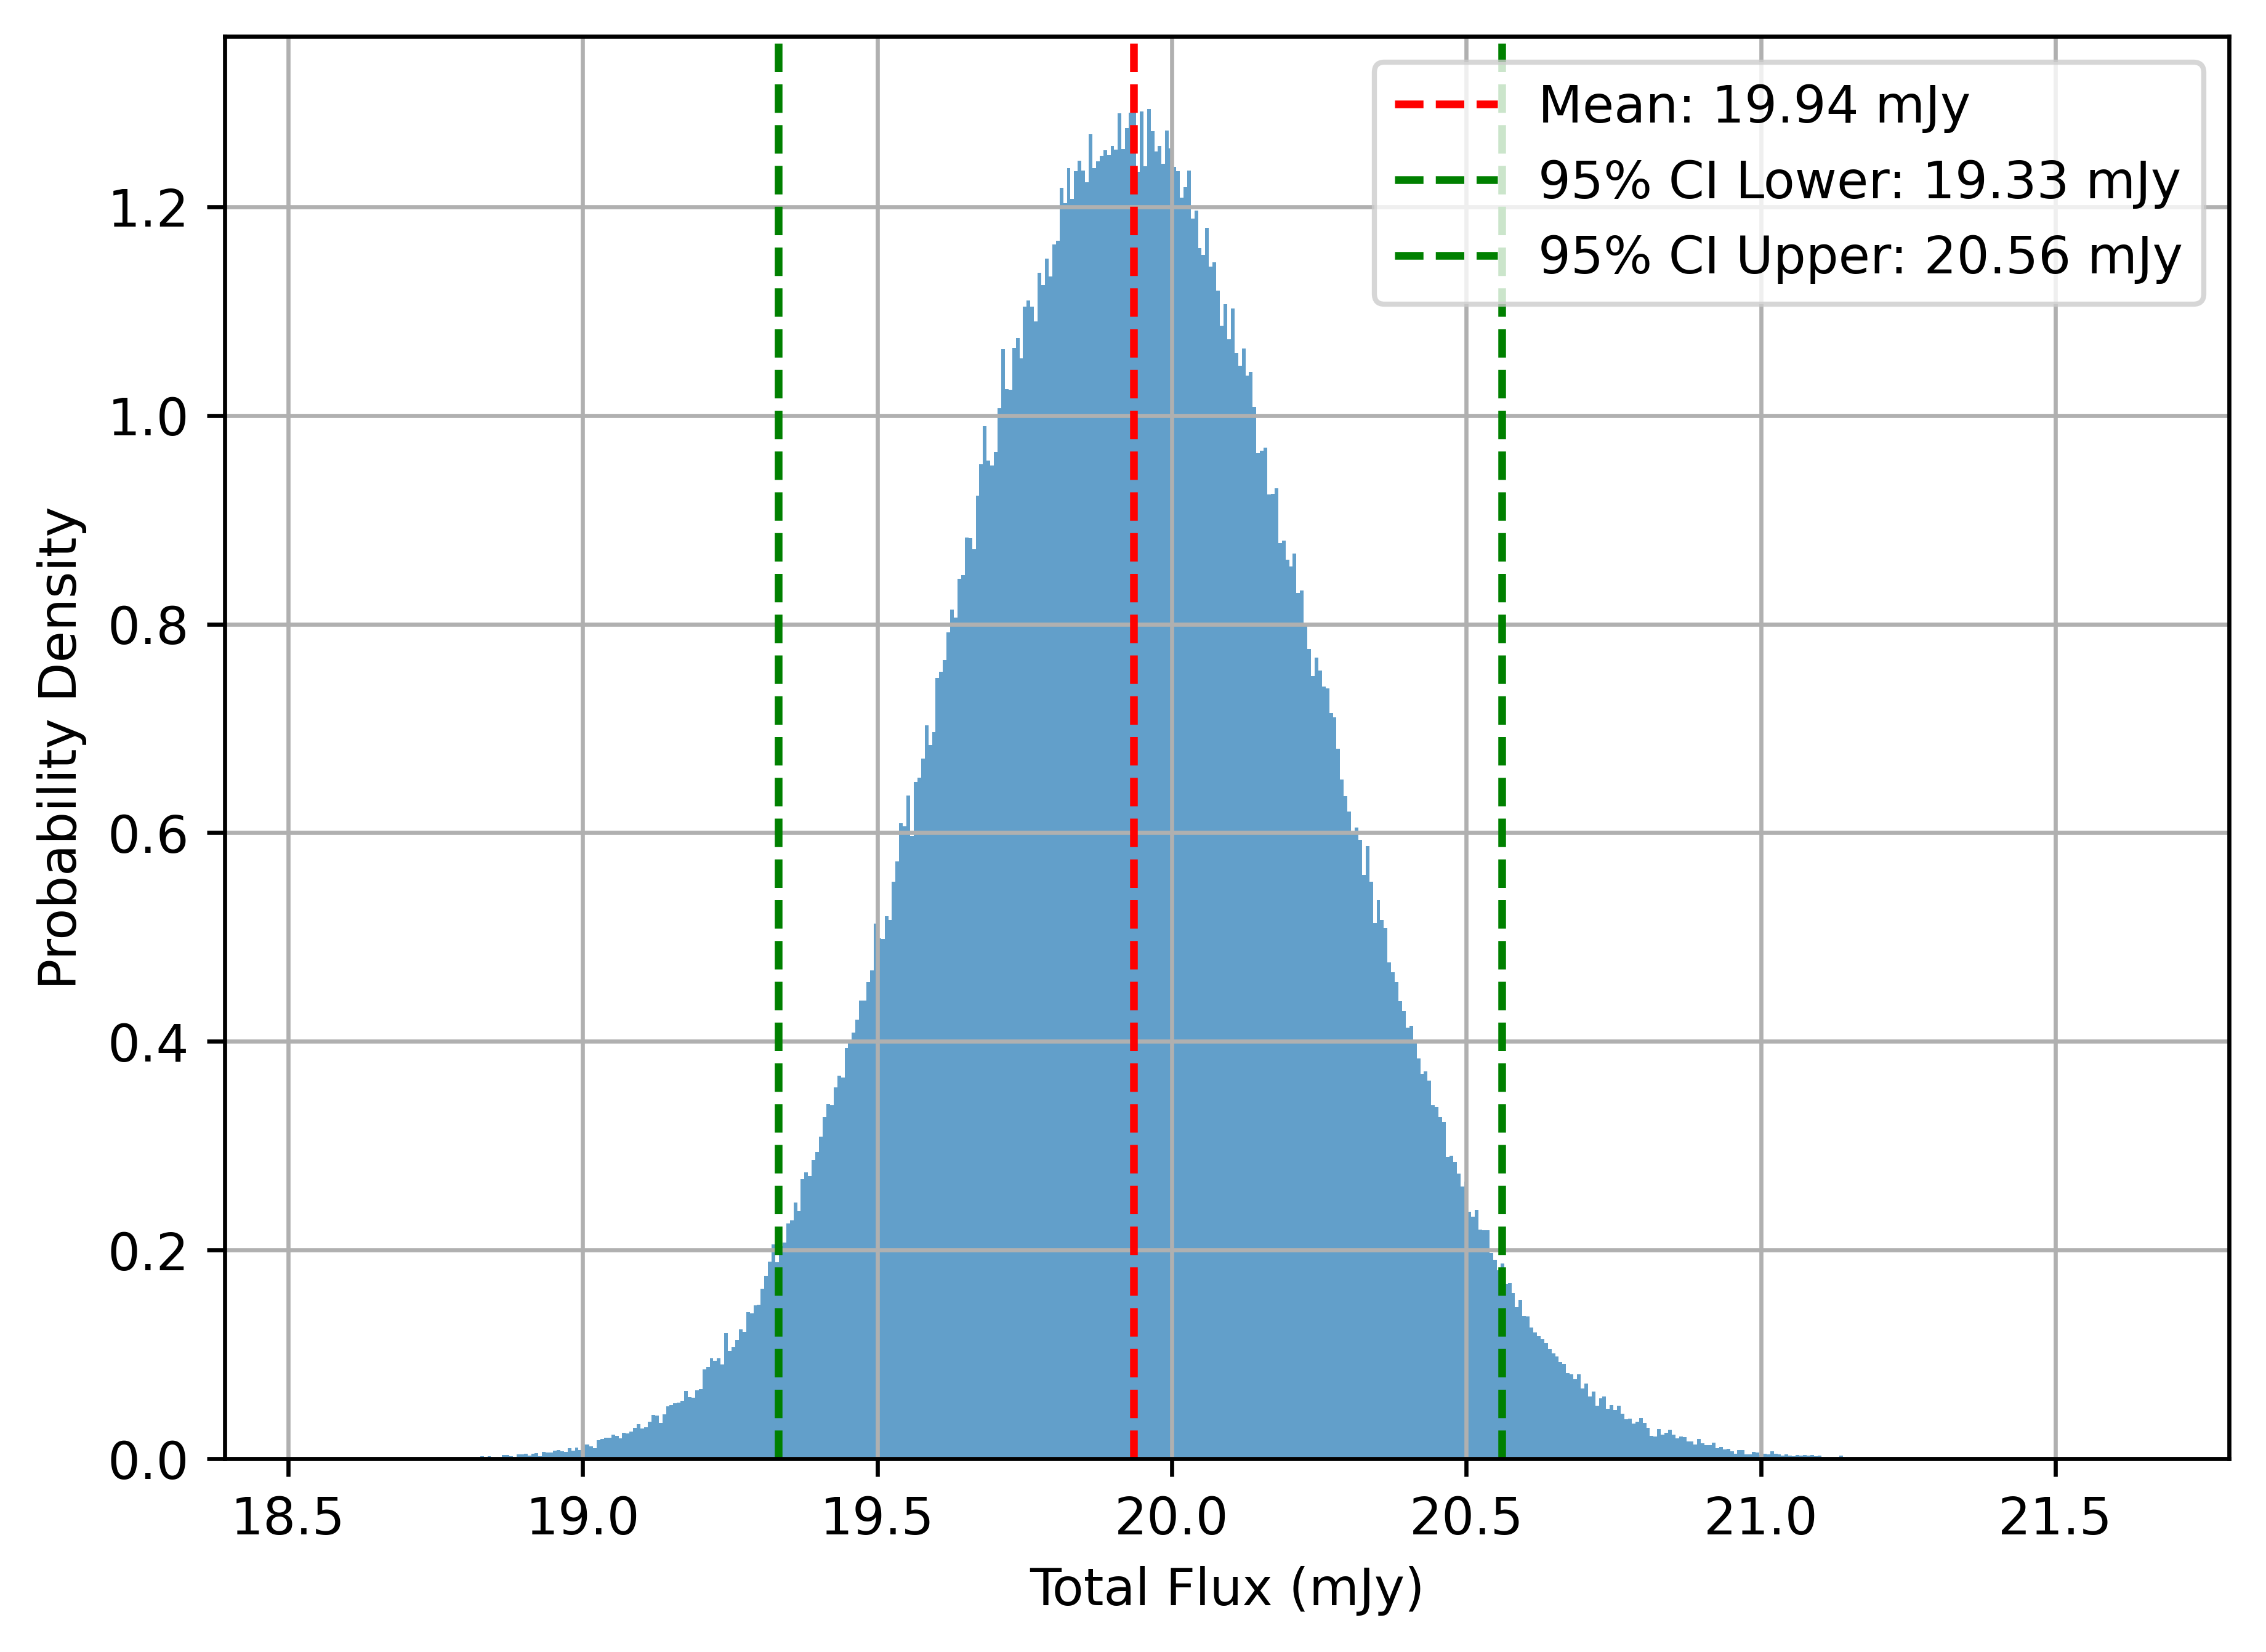

Filter: F356W
Adjusted inner radius for image 1 to 1.27 pixels based on 1 lambda/D.
Processing took: 18.3034 seconds
Mean Total Flux: 3.419619 mJy
Standard Deviation of Total Flux: 0.091031 mJy


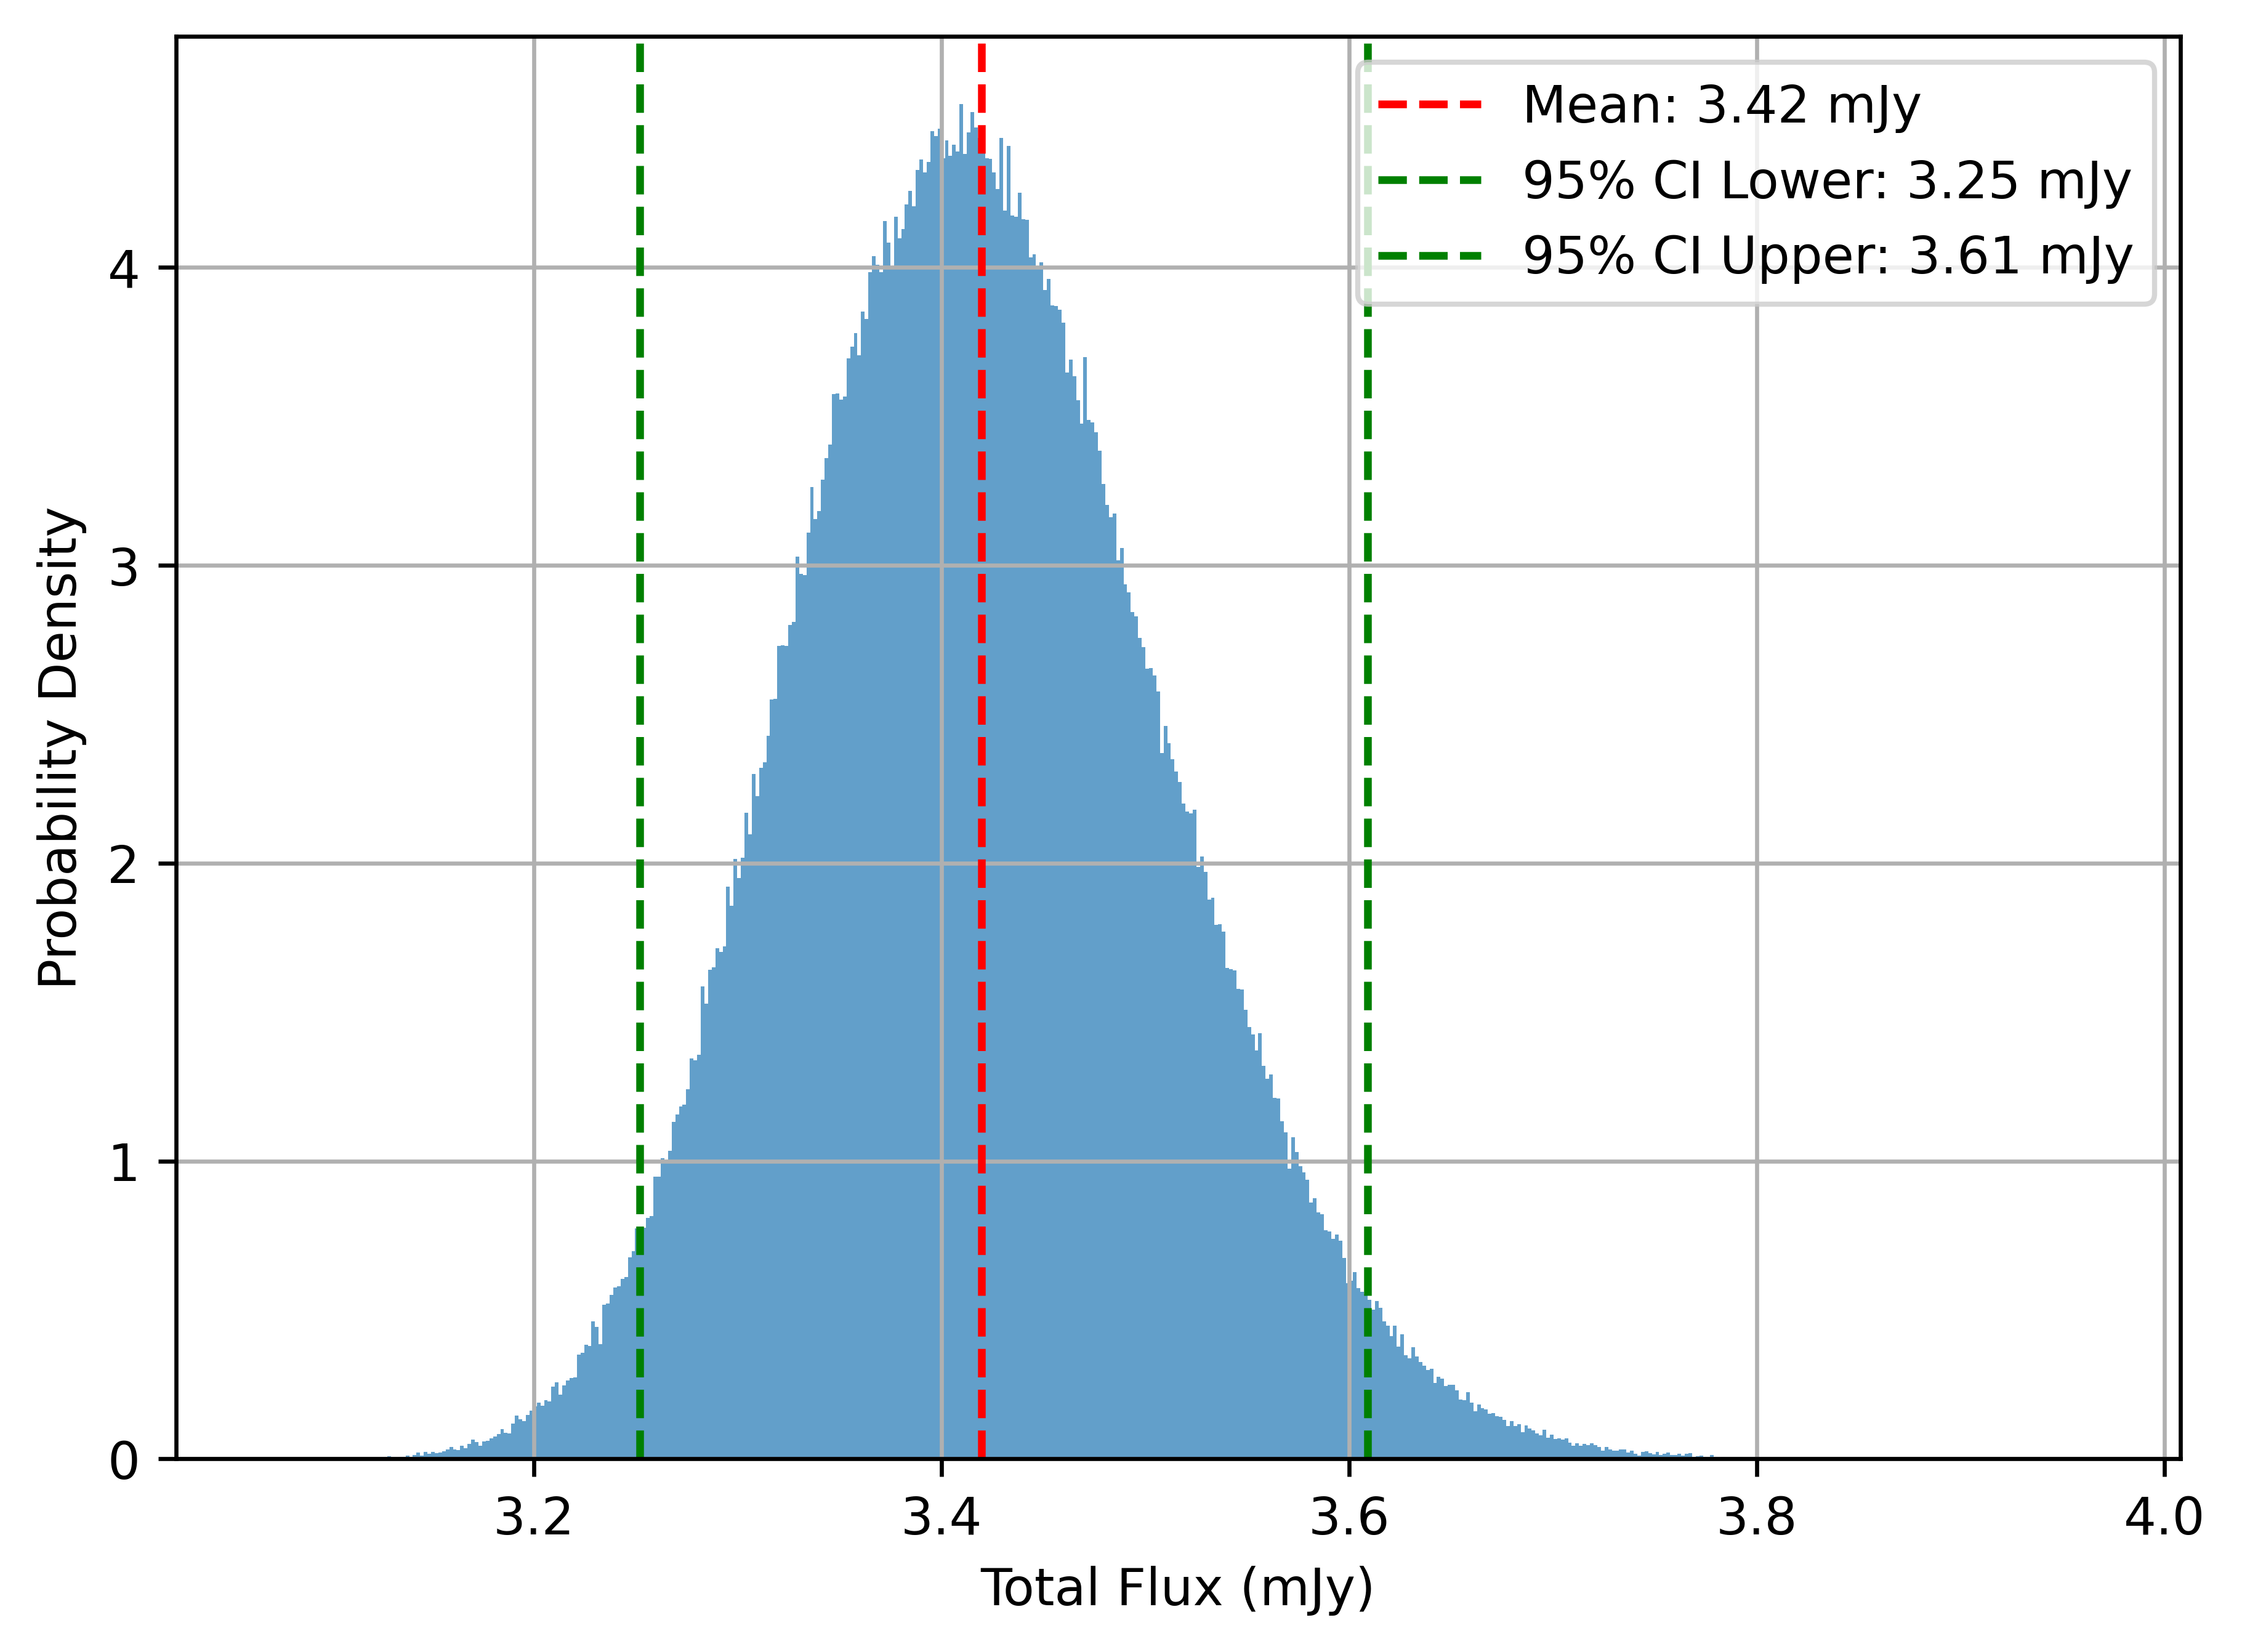

Filter: F444W
Adjusted inner radius for image 2 to 2.26 pixels based on 1 lambda/D.
Processing took: 18.0562 seconds
Mean Total Flux: 2.738869 mJy
Standard Deviation of Total Flux: 0.059583 mJy


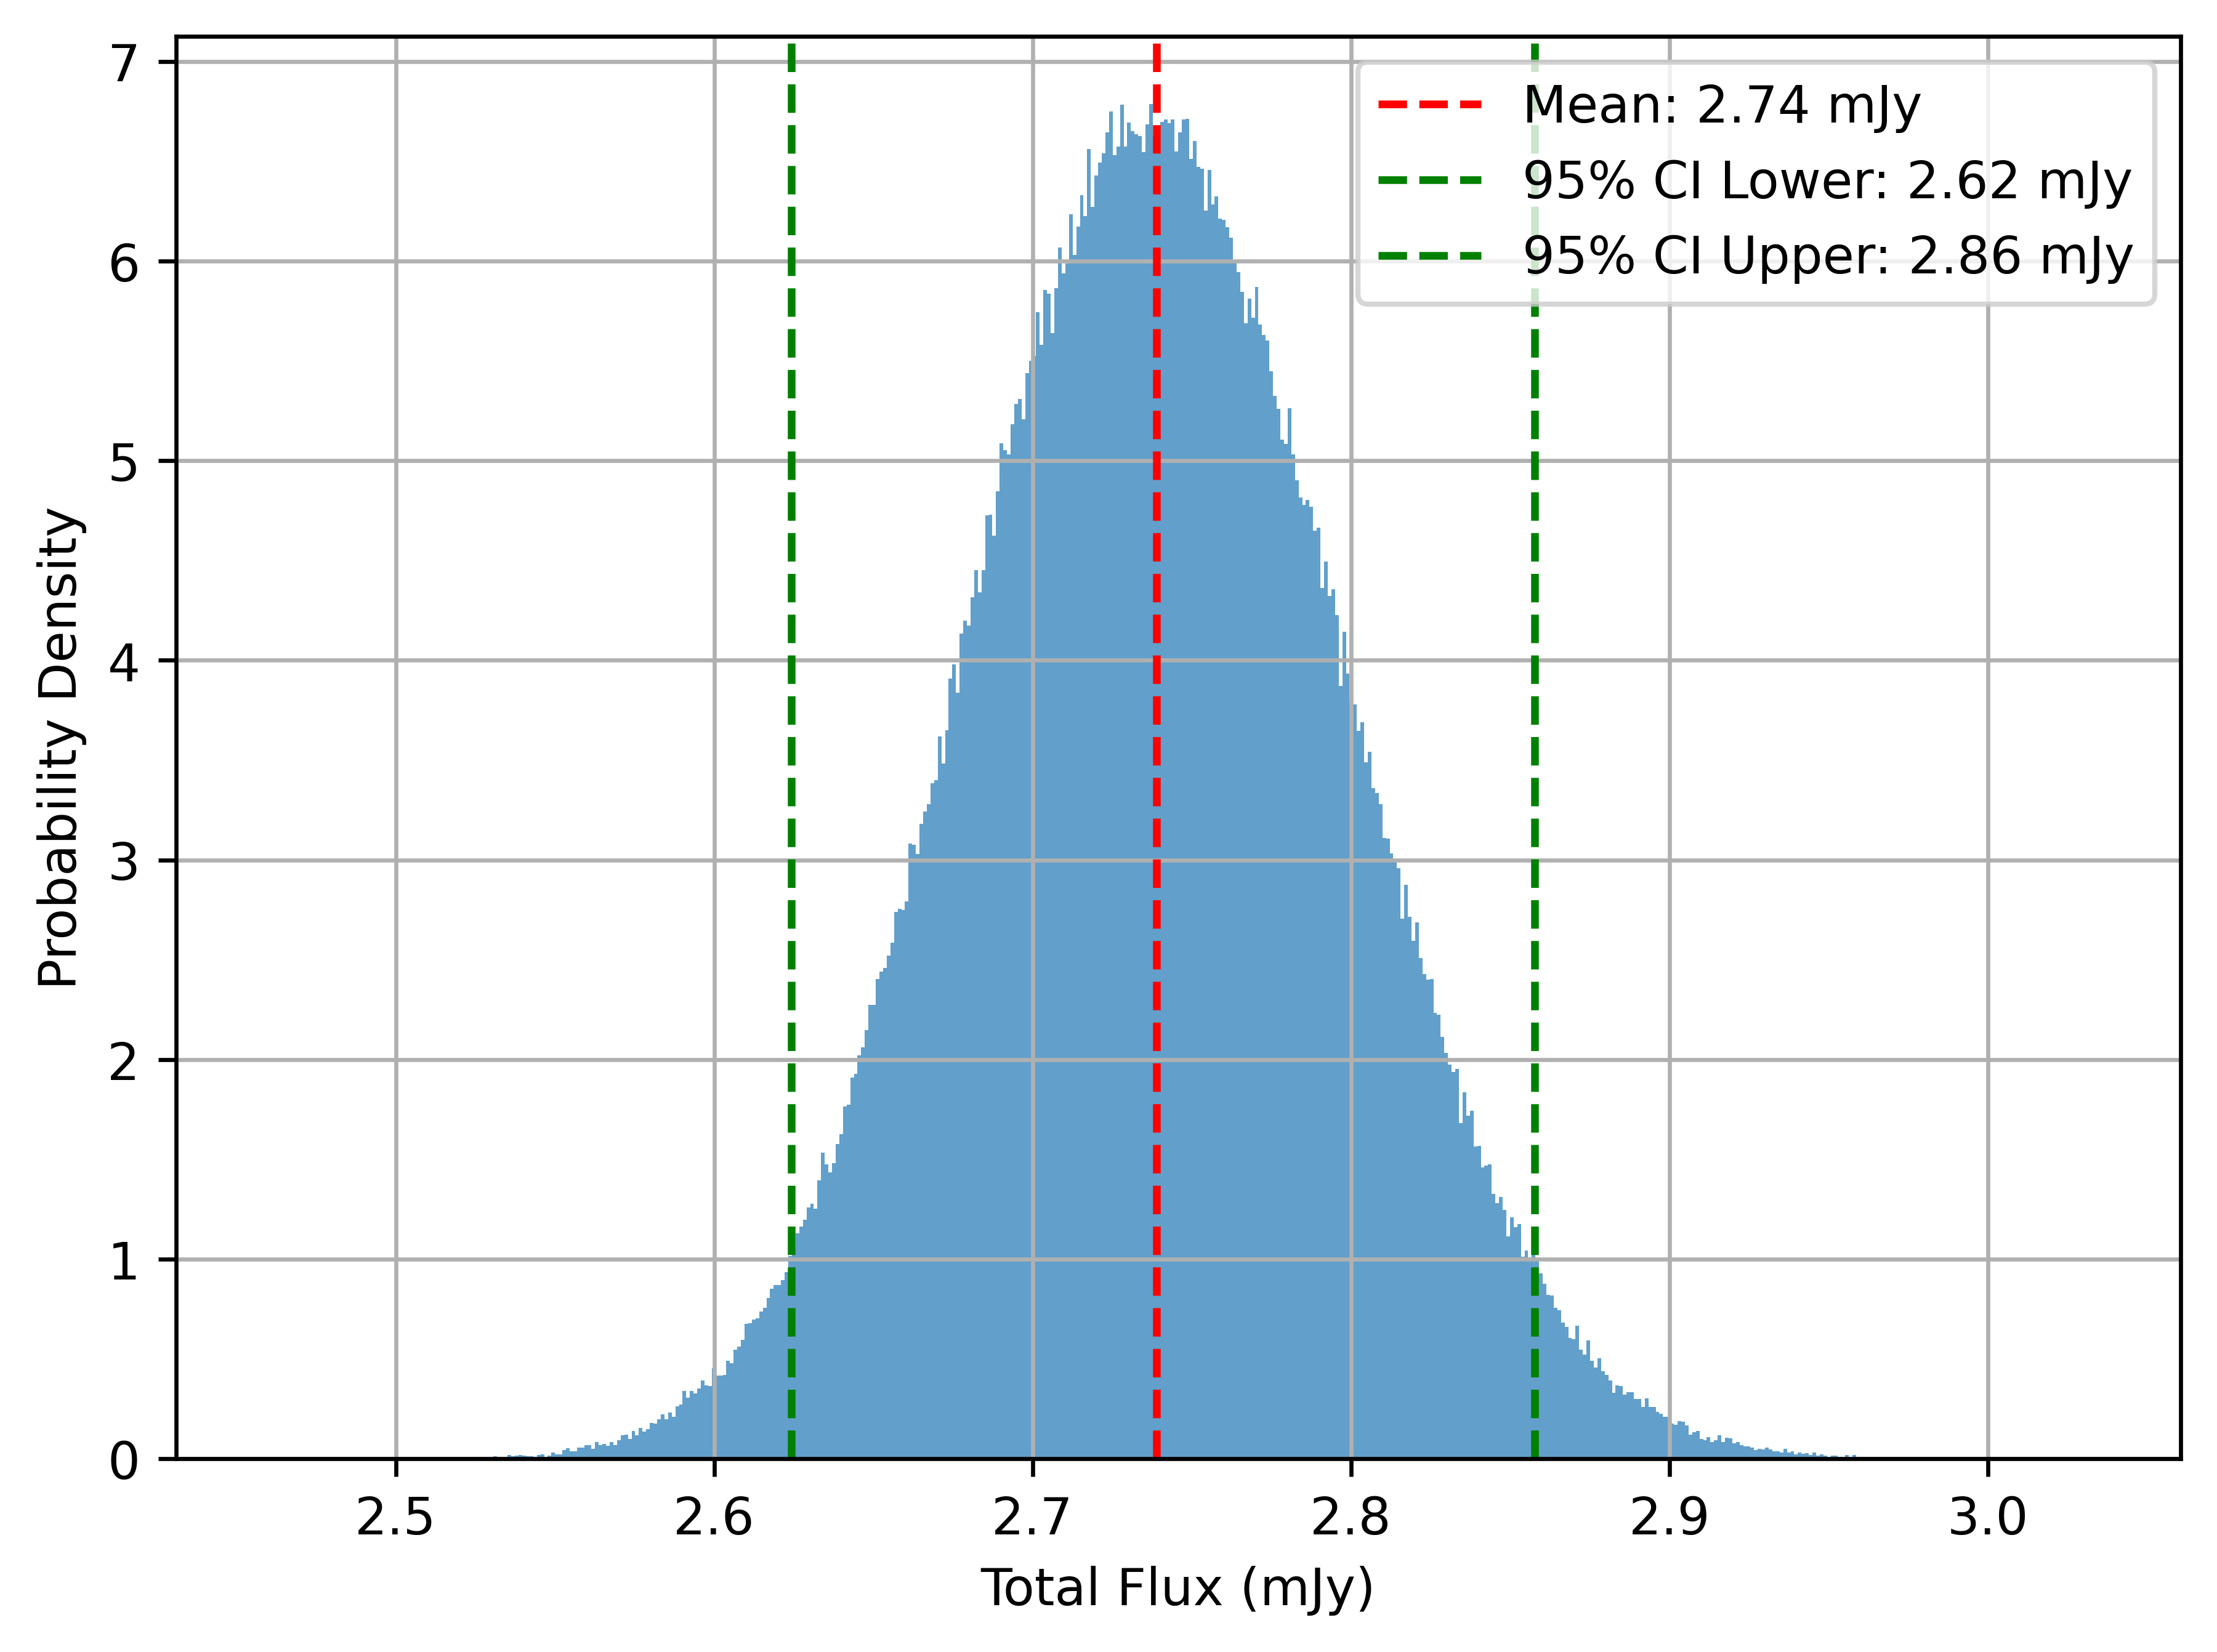



Throughput Corrected Images Photometry
Filter: F200W
Adjusted inner radius for image 0 to 2.42 pixels based on 1 lambda/D.
Processing took: 17.6124 seconds
Mean Total Flux: 22.973305 mJy
Standard Deviation of Total Flux: 0.066352 mJy


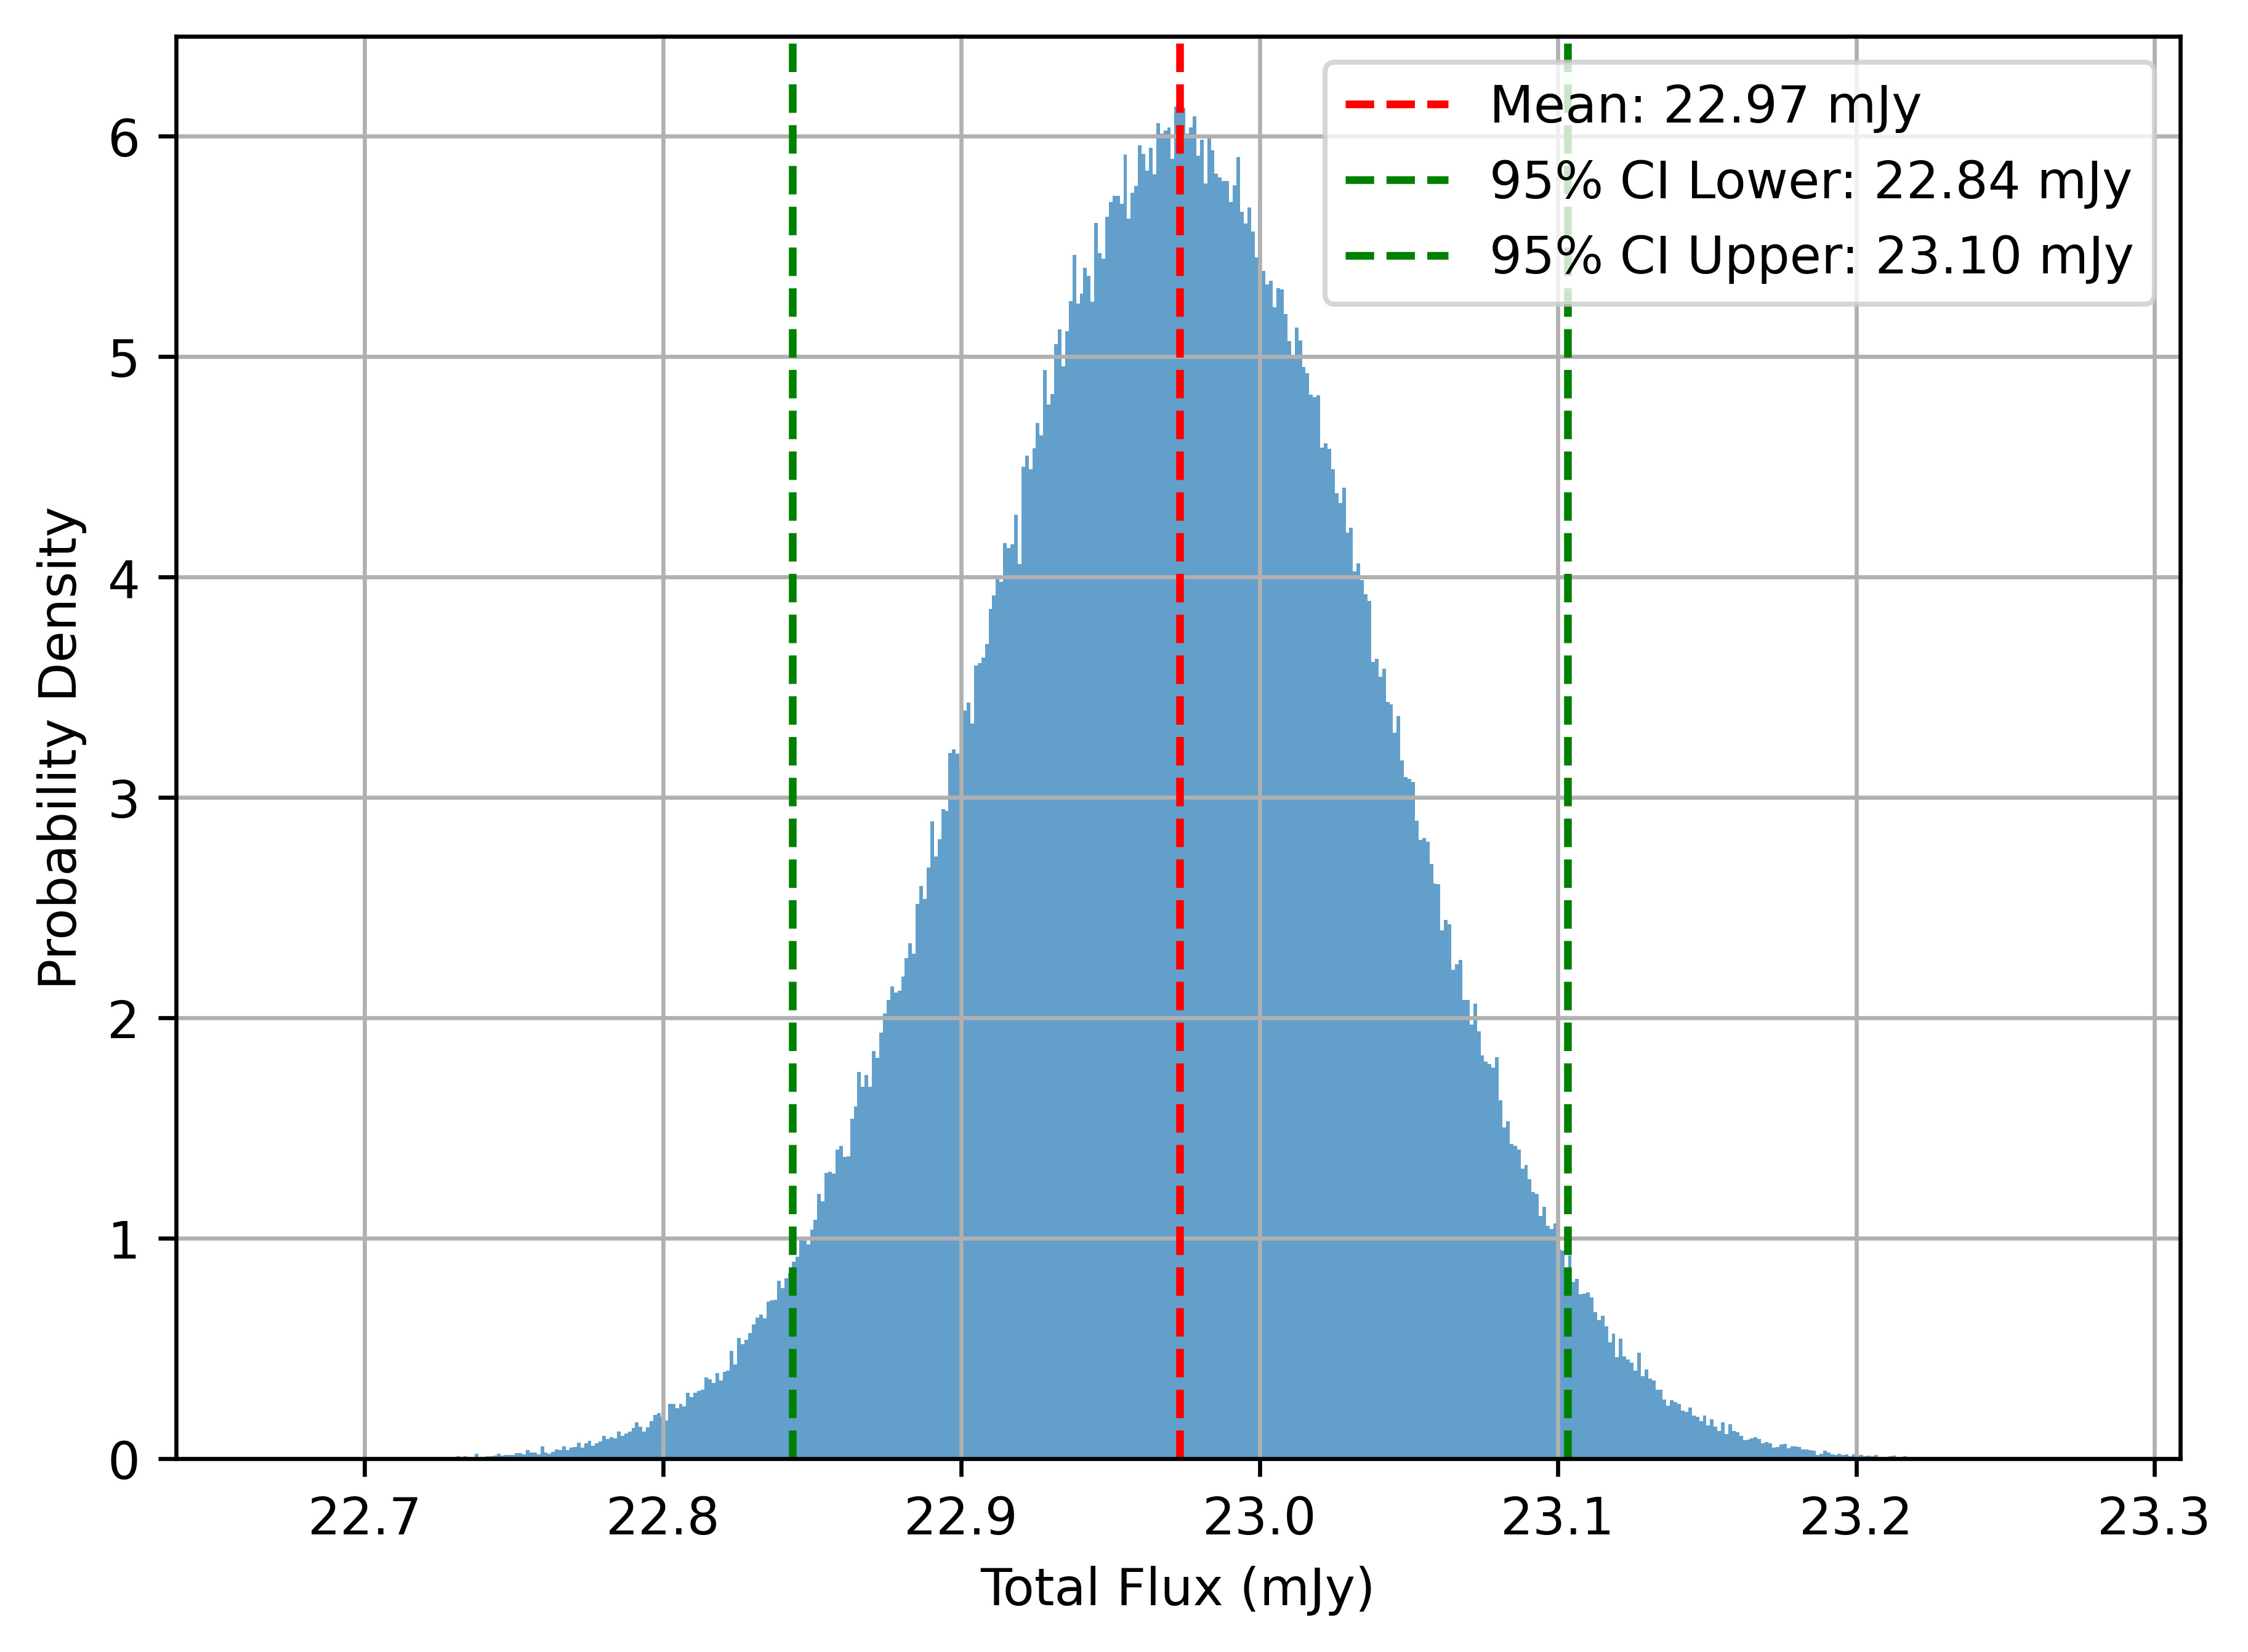

Filter: F356W
Adjusted inner radius for image 1 to 1.27 pixels based on 1 lambda/D.
Processing took: 17.9385 seconds
Mean Total Flux: 6.241253 mJy
Standard Deviation of Total Flux: 0.112315 mJy


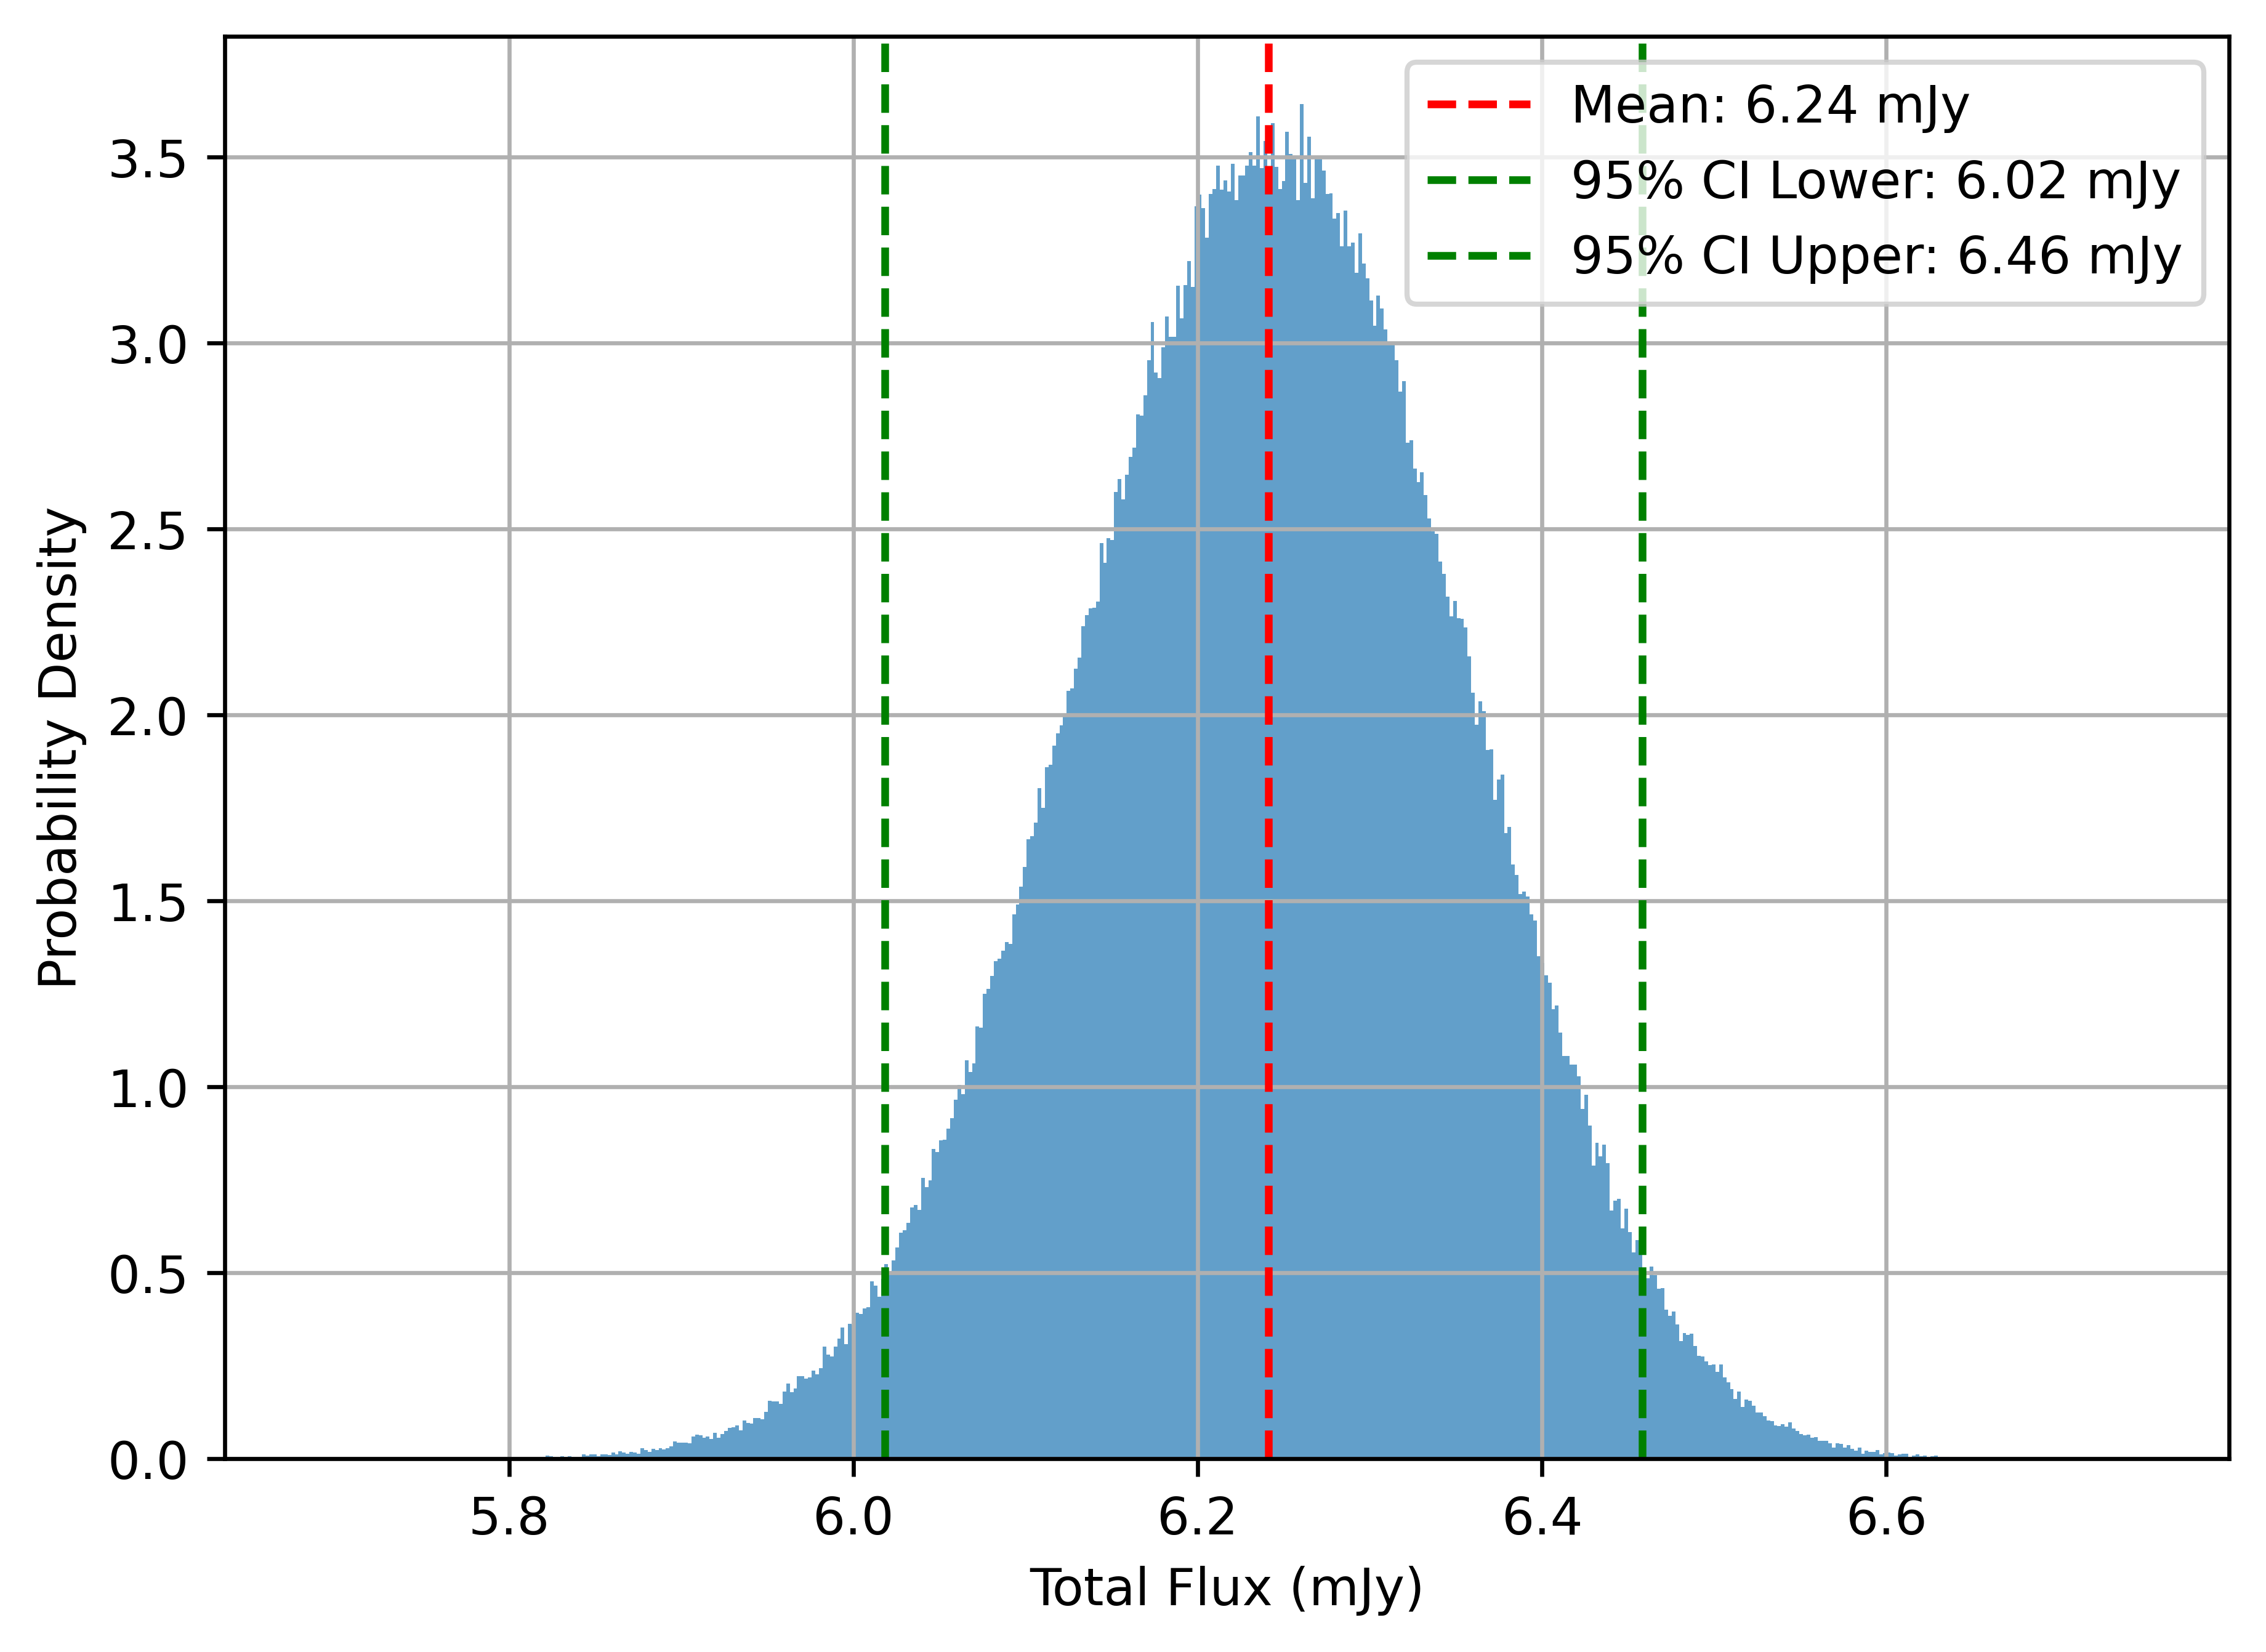

Filter: F444W
Adjusted inner radius for image 2 to 2.26 pixels based on 1 lambda/D.
Processing took: 18.9914 seconds
Mean Total Flux: 3.302085 mJy
Standard Deviation of Total Flux: 0.025245 mJy


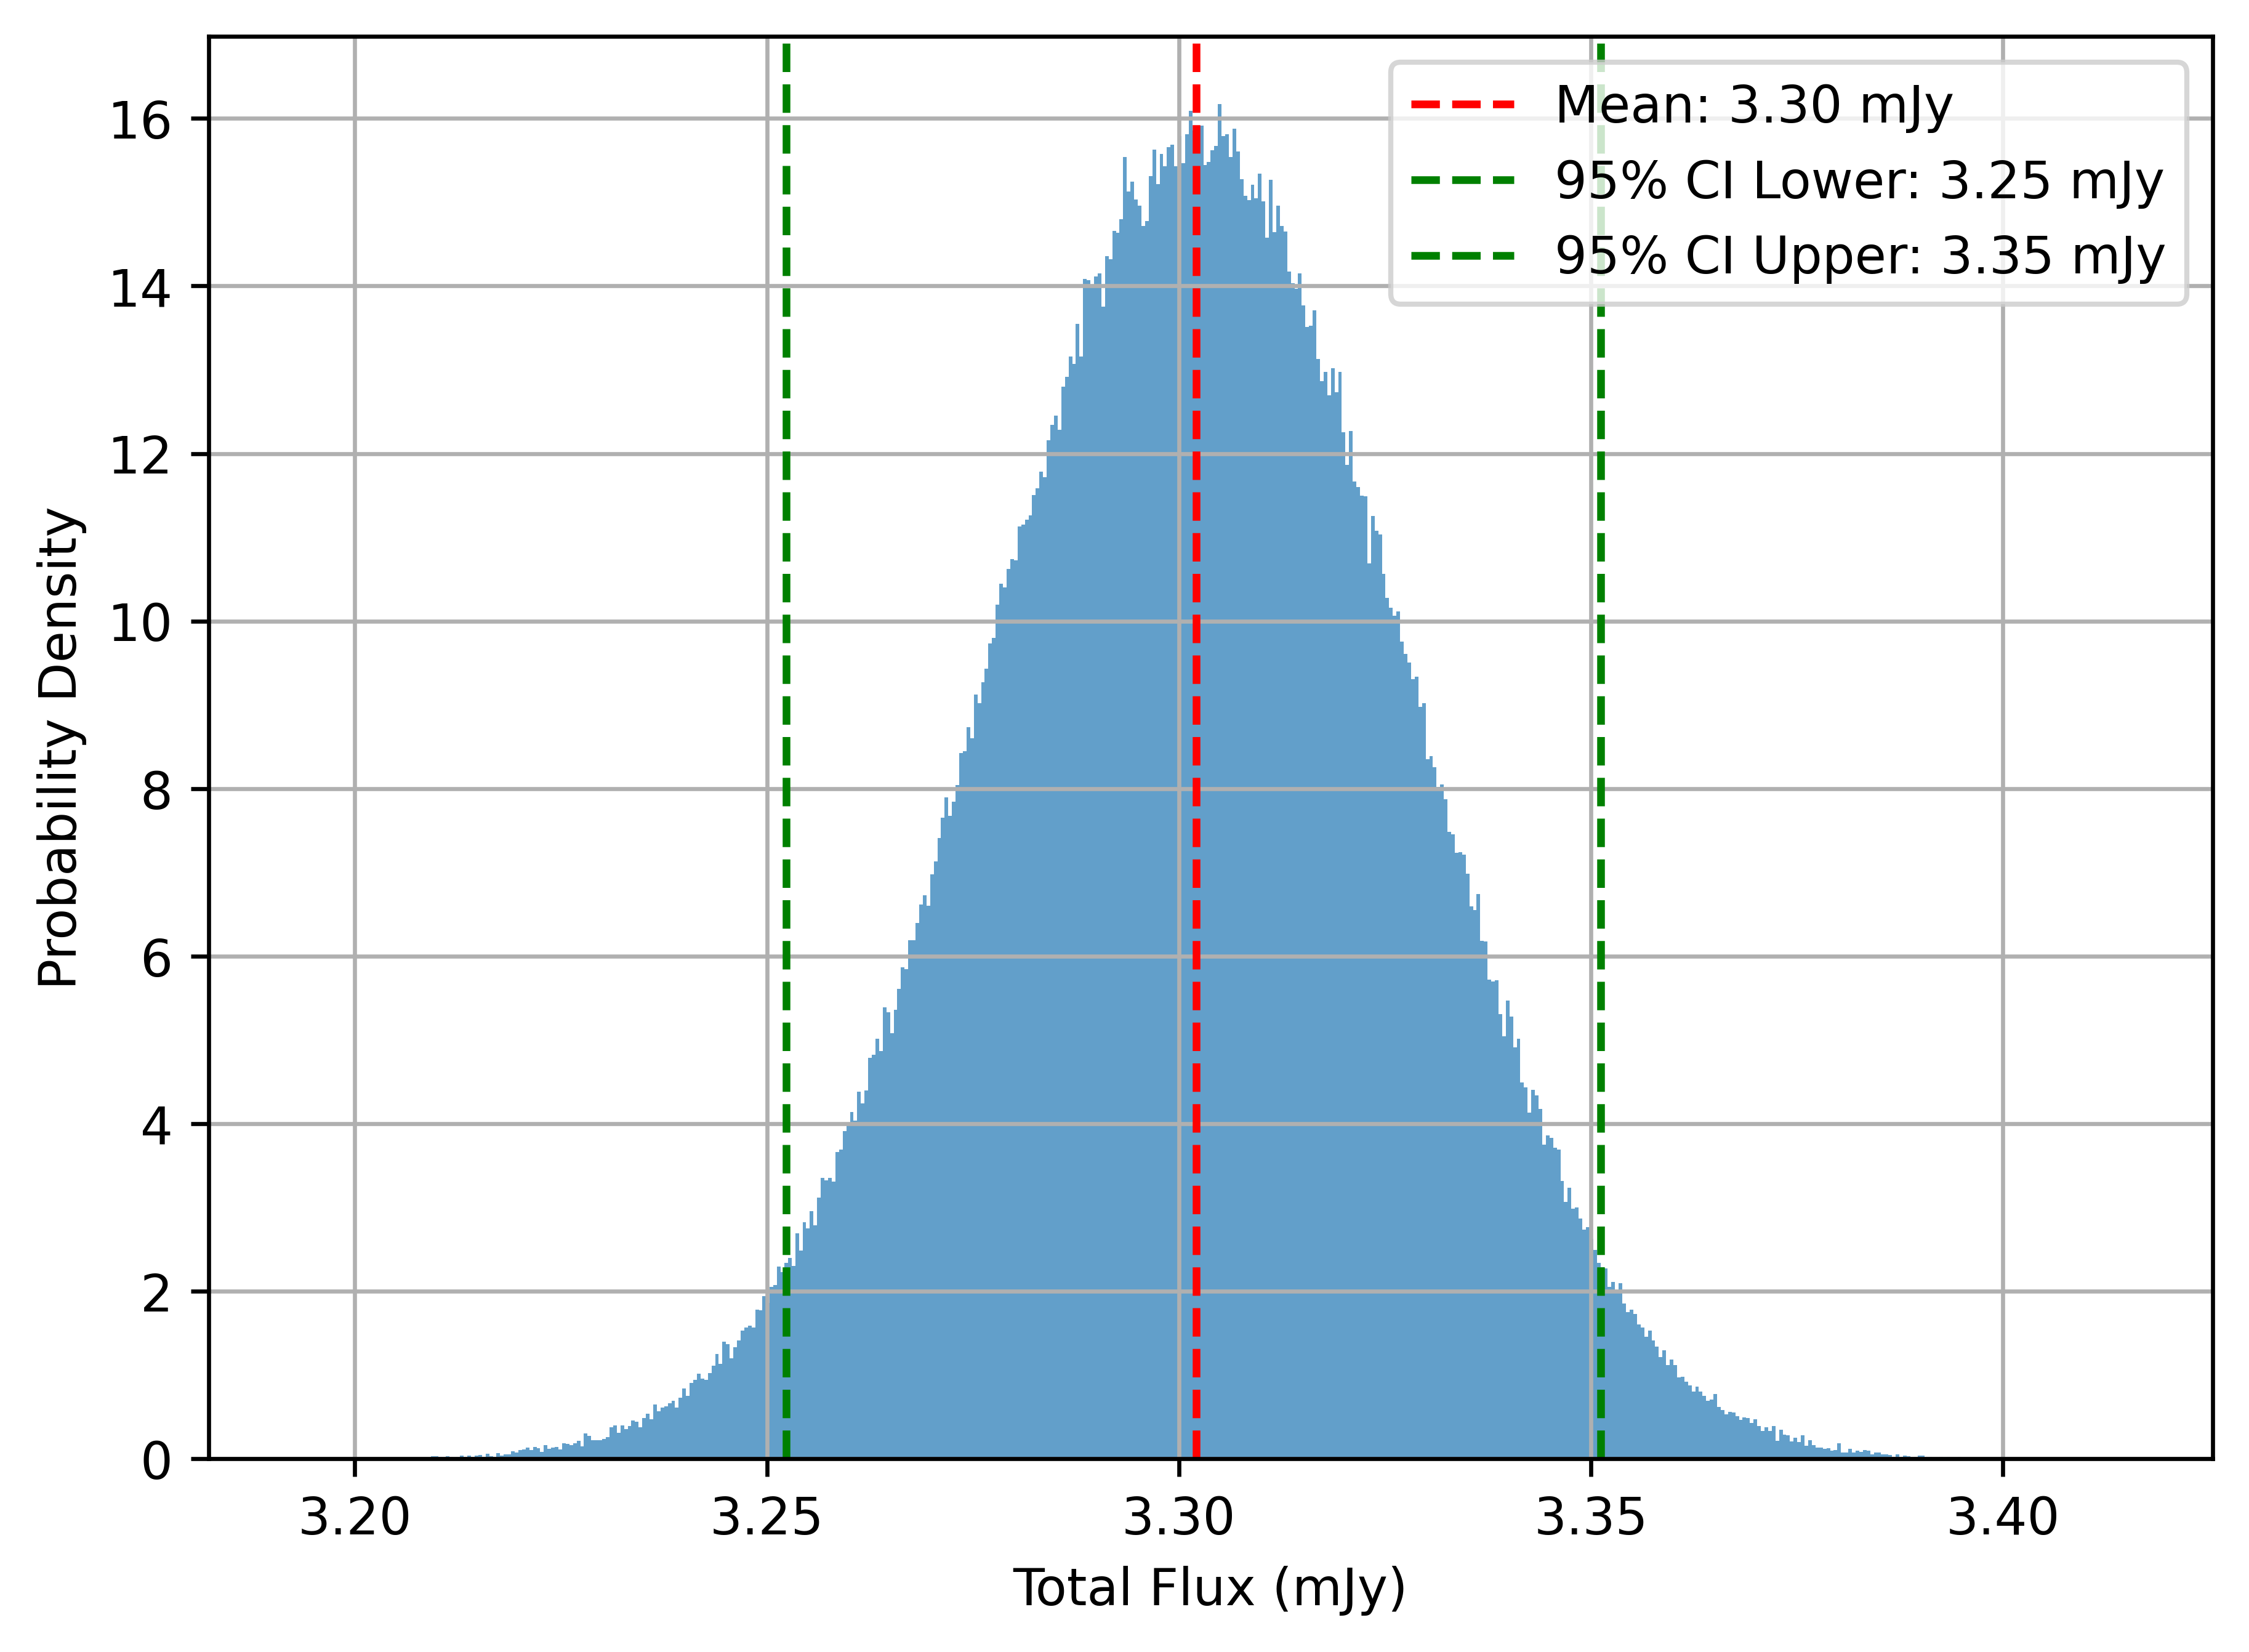

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import time
# Import the Rust module we just built
import rust_bootstrap

# Setting for a ring clipping mask
r_in = [0,0,0,0]  # inner radius in pixels
wavelengths = [1.87e-6, 2.00e-6, 3.56e-6, 4.44e-6]  # wavelengths in meters
D = 5.2  # JWST Nircam Coro primary mirror diameter in meters
r_out = [324,324,324,324]  # outer radius in pixels
x_center, y_center = 324.5, 324.5  # center of the ring in pixels

# Constant
conversion_factor = 2.3504e-2 # mJy/arcsec^2 per MJy/sr

# --- Bootstrap analysis ---
n_bootstrap = 500000 # Number of bootstrap samples

def bootstrap_photometry_rust(images, headers, pixel_scales, n_bootstrap, ignore_r_lambda_D = 1):
    """
    Performs bootstrap photometry on a list of images using the high-performance Rust core.
    """
    # Remove the innermost region if specified
    bootstrap_fluxes = np.empty(len(images))
    bootstrap_efluxes = np.empty(len(images))
    for i, (image, header, pixel_scale) in enumerate(zip(images, headers, pixel_scales)):
        start_time = time.time()
        if 'filter' in header:
            print(f"Filter: {header['filter']}")
            
        # 1. Vectorized Grid and Radius Calculation (same as before)
        ny, nx = image.shape
        y_indices, x_indices = np.mgrid[:ny, :nx]
        radii = np.sqrt((x_indices - x_center)**2 + (y_indices - y_center)**2)

        # 2. Fast Pixel Masking
        if ignore_r_lambda_D:
            # lambda / D in pixels
            lambda_D_pixels = [ (wavelength / D) / (pixel_scale * (np.pi / 648000)) for wavelength, pixel_scale in zip(wavelengths, pixel_scales)]
            r_inner = max(r_in[i], ignore_r_lambda_D * lambda_D_pixels[i])
            print(f"Adjusted inner radius for image {i} to {r_inner:.2f} pixels based on {ignore_r_lambda_D} lambda/D.")
        valid_mask = (radii >= r_inner) & (radii < r_out[i]) & ~np.isnan(image)
        valid_pixels = image[valid_mask].astype(np.float64)
        valid_radii_integers = radii[valid_mask].astype(np.int32)
        
        # 3. Call the high-performance Rust core function
        # This single line replaces the entire Python loop for bootstrapping.
        bootstrap_sums = rust_bootstrap.bootstrap_core(
            valid_pixels, 
            valid_radii_integers, 
            n_bootstrap
        )

        # 4. Final Flux Calculation (same as before)
        total_fluxes_bootstrap = bootstrap_sums * (pixel_scale**2) * conversion_factor

        # --- Analysis and Plotting (same as before) ---
        mean_flux = np.mean(total_fluxes_bootstrap)
        std_flux = np.std(total_fluxes_bootstrap)
        
        end_time = time.time()
        print(f"Processing took: {end_time - start_time:.4f} seconds")
        print(f"Mean Total Flux: {mean_flux:.6f} mJy")
        print(f"Standard Deviation of Total Flux: {std_flux:.6f} mJy")
        
        plt.figure(figsize=(7, 5), dpi=600)
        plt.hist(total_fluxes_bootstrap, bins=500, density=True, alpha=0.7)
        plt.xlabel('Total Flux (mJy)')
        plt.ylabel('Probability Density')
        plt.axvline(mean_flux, color='r', linestyle='--', label=f'Mean: {mean_flux:.2f} mJy')
        # add 95% confidence interval lines
        ci_lower = np.percentile(total_fluxes_bootstrap, 2.5)
        ci_upper = np.percentile(total_fluxes_bootstrap, 97.5)
        plt.axvline(ci_lower, color='g', linestyle='--', label=f'95% CI Lower: {ci_lower:.2f} mJy')
        plt.axvline(ci_upper, color='g', linestyle='--', label=f'95% CI Upper: {ci_upper:.2f} mJy')
        plt.legend()
        plt.grid(True)
        plt.show() # Commenting out to avoid multiple blocking popups in this environment

        bootstrap_fluxes[i] = mean_flux
        bootstrap_efluxes[i] = std_flux
        
    return bootstrap_fluxes, bootstrap_efluxes

# HPFRDI Images Photometry
print("HPFRDI Images Photometry")
hpfrdi_fluxes, hpfrdi_efluxes = bootstrap_photometry_rust(hpfrdi_images, headers, pixel_scales, n_bootstrap)

print("\n" + "="*50 + "\n")

# Deconvolved Images Photometry
print("Deconvolved Images Photometry")
deconv_fluxes, deconv_efluxes = bootstrap_photometry_rust(deconv_images, headers, pixel_scales, n_bootstrap)

# Throughput Corrected Images Photometry
print("\n" + "="*50 + "\n")
print("Throughput Corrected Images Photometry")
throughput_fluxes, throughput_efluxes = bootstrap_photometry_rust(throughput_images, headers, pixel_scales, n_bootstrap)